In [436]:
# load a matrix from a space-separated file and show it as an image
import sys
sys.path.append('/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/')
sys.path.append('/homes/ar2342/one_more_dir/contextual_frogs/')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import os
from stat_utils import bic_gaussian_from_rmse


In [437]:
def compute_k_params(model_state_dict, 
                     exclude_by_startwith=['_'], 
                     exclude_by_name=['sigma_x'], 
                     count_for_one={'sigma_b', 'direct_injection_scale','output_scale','u_feedback_scale'}):
    k_params = 0
    for key in model_state_dict:
        if any([key.startswith(excl) for excl in exclude_by_startwith]):
            continue
        if key in exclude_by_name:
            continue
        param_tensor = model_state_dict[key]
        this_param_size = param_tensor.shape[-1] if key not in count_for_one else 1
        print(f'param: {key}, size: {this_param_size}')
        k_params += this_param_size
    return k_params

In [438]:
from models_part2 import BatchedElboGenerativeModelTopMulti
import yaml
from types import SimpleNamespace
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [439]:
import pickle

In [440]:
template = 'multirate' #multiscale_feedback' #'lr_reduct'#  'multirate'#'state-space'
mode = 'ERSR'
n_subjects = 1
n_seeds = 1
priority_intervals = None
priority_factor = None

if template == 'multirate':
    args = SimpleNamespace(
        model='default',
        enable_q_scale_tuning= mode == 'MU',
        assume_opt_output_noise=True,
        enable_qlpf=False,
        enable_ylpf=False,
        enable_elpf=False,
        multirate_m=1,          # 
        apply_lr_decay=False, #False,
        noise_injection_node='a',
        model_tie_lr_weight_decay=False,
        bs=n_subjects * n_seeds,                      # IMPORTANT: one batch entry per subject
        zzz_legacy_init=False,
        enable_output_scale_tuning= True, #False,# mode == 'MU',
        enable_u_feedback_scale_tuning=False, #True,
        enable_direct_injection= True , #mode == 'MU',
        injection_opt=3,            # 
        skip_gain=0.0,
        channel_trial_extra_error=0.0,
        lr_min_mult = 1e-1,
        weight_decay_mode='softplus', #'sigmoid', #
        # weight_decay_mode='clipped_sigmoid',
        weight_decay_max=1.0,
        nl_activation= 'relu',#,'rescaled_sigmoid',#'rescaled_sigmoid',#'relu', #['relu', 'const'], # 'rescaled_sigmoid', #'relu', #
        n=128 if mode == 'ERSR' else 256,
        disable_lpfs=True,
        optimizer_alg= 'RMSprop', # 'RMSprop',
        n_seeds=n_seeds,
        priority_intervals=priority_intervals,
        priority_factor=priority_factor,
        lr_bound = None, #1./512.,
        bound_weight_decay = True,
        enable_weight_learning_exp = False,
        enable_weight_decay_exp = False,
        enable_bias_update = False,
        develop_b_tgt = -2.0,
        enable_w_in_plasticity = True,
        enable_separate_win_per_rate = False,
        debug_flag_win2nd_column_positive_only = False,
        enforce_positive_biases = False,
        initiate_w_in_tuning_with_steady_state_vals = True,
        # manual_w_in_scale = 1e-5,
        # direct_inj_limiter=0.45,
    )

In [441]:
model = BatchedElboGenerativeModelTopMulti(device=device, args=args).to(device)
_ =model.get_biases_and_w_in(args.n, device=device)


In [442]:
model_state_dict = model.state_dict()
k_params = compute_k_params(model_state_dict)

param: log_learning_rate, size: 1
param: sigma_b, size: 1
param: output_scale, size: 1
param: sp_weight_decay, size: 1
param: w_in_lr_, size: 1
param: w_in_decay_, size: 1
param: direct_injection_scale, size: 1


In [443]:
from model_utils import force_model_params




In [444]:
n_subjects=16

In [445]:
from optimise_clnn import load_subject_data

all_ys = []
all_a_exp = []
all_qs = []
lengths = []

mode =  'ERSR' #'ERSR' #'MU' 
paradigm_ = {k: 'evoked' if k <= 8 else 'spontaneous' for k in range(1, 17)}

for k in range(1, n_subjects + 1):
    if mode == 'ERSR':
        csv_path = f'/homes/ar2342/frogs_project/data/COIN_data/trial_data_{paradigm_[k]}_recovery_participant{(k-1)%8+1}.csv'
    else:
        csv_path = f'/homes/ar2342/frogs_project/data/COIN_data/trial_data_memory_updating_participant{k}.csv'
    experimental_data = load_subject_data(csv_path)

    a_exp = np.asarray(experimental_data[0], dtype=np.float32)  # target (your a_exp)
    ys    = np.asarray(experimental_data[1], dtype=np.float32)  # input ys (your ys)
    if mode == 'MU':
        qs = np.asarray(experimental_data[2], dtype=np.float32)  # input qs (your qs)

    for _ in range(n_seeds):
        all_a_exp.append(a_exp)
        all_ys.append(ys)
        if mode == 'MU':
            all_qs.append(qs)
        lengths.append(len(a_exp))

In [446]:
def create_ys_and_noises(ys, args, model):
    ys = ys.unsqueeze(0).repeat(args.bs, 1)  # [bs, t]
    noises = torch.zeros((args.bs, ys.shape[1]), device=next(model.parameters()).device)  # [bs, t]
    noises = [noises[:, t_idx] for t_idx in range(noises.shape[1])]
    ys = [ys[:, t_idx] for t_idx in range(ys.shape[1])]
    return ys, noises

In [447]:
def pad(sequence, pad_value=0.0, n=0, where='start', axis=0):
    #pads a torch tensor or a numpy array with n repeats of pad_value at the start or end of a specified axis
    if isinstance(sequence, np.ndarray):
        pad_shape = list(sequence.shape)
        pad_shape[axis] = n
        pad_tensor = np.full(pad_shape, pad_value, dtype=sequence.dtype)
        if where == 'start':
            padded_sequence = np.concatenate([pad_tensor, sequence], axis=axis)
        elif where == 'end':
            padded_sequence = np.concatenate([sequence, pad_tensor], axis=axis)
        else:
            raise ValueError("where must be 'start' or 'end'")
        return padded_sequence
    elif isinstance(sequence, torch.Tensor):
        pad_shape = list(sequence.shape)
        pad_shape[axis] = n
        pad_tensor = torch.full(pad_shape, pad_value, device=sequence.device)
        if where == 'start':
            padded_sequence = torch.cat([pad_tensor, sequence], dim=axis)
        elif where == 'end':
            padded_sequence = torch.cat([sequence, pad_tensor], dim=axis)
        else:
            raise ValueError("where must be 'start' or 'end'")
        return padded_sequence

In [474]:
outputs = []
outputs_ab = []
outputs_ac = []
ys_ab = np.concatenate([np.zeros(100), np.ones(200), -np.ones(200), ])
ys_ab = torch.tensor(ys_ab, device=next(model.parameters()).device)  # [1, t]
ys_ac = np.concatenate([np.zeros(100), np.ones(200), np.nan*np.ones(200), ])
ys_ac = torch.tensor(ys_ac, device=next(model.parameters()).device)  # [1, t]
warmup = 0# 200
model.args.initiate_w_in_tuning_with_steady_state_vals = False
model.w_in_scale = torch.tensor([1.0e-5], device=next(model.parameters()).device)
# model.w_in_scale = torch.tensor([[1.0e-5]], device=next(model.parameters()).device)
# pp_list = [0.25, 0.5,1,2,3]
# pp_list = [0.0,1e-3,3e-3,5e-3,7e-3,1e-2]#3e-2,1e-1]
# pp_list = [0.0,1e-2, 2e-2,5e-2]#3e-2,1e-1]
# pp_list = [-0.8,-0.5,-0.3, -0.2, -0.1, 0.0,0.1,]
pp_list = [-0.8,-0.7,-0.6,-0.5,-0.3] # -0.2, -0.1, 0.0,0.1,]
# pp_list = [0.1]
this_sub_indx=0
# pp_list = [0.9999, 0.999, 0.99, 0.98, 0.95, 0.9] # just run the default params
for pp in pp_list:
    forced_params = {
                    # 'log_learning_rate_decay': 0.5, 
                    # 'sigma_x': 1e-7, 
                    'log_learning_rate': torch.tensor([-4.00]),
                    'sp_weight_decay': torch.tensor([-60.5]),
                    'w_in_lr_': torch.tensor([0.035/4]),
                    'w_in_decay_': torch.tensor([0.01/4]),
                    # 'output_scale': 1.0,
                    # 'u_feedback_scale': 1.0,
                    'sigma_b': 0.2,
                    # 'x_fast_alpha': 0.0,
                    # 'x_fast_gain': 0.8,
                    # 'x_slow_alpha': 0.99,
                    #'q_scale': 0.9,
                    #  'tauelpf_m1': -1000.0,
                    #  'tauqlpf_m1': -1000.0,
                     'direct_injection_scale': pp,
                    'weight_learning_exp': 1.0,
                    # 'weight_decay_exp': 1.0,
                    # 'bias_lr':0.0,
                    # 'w_in_lr': 1e-4,#pp,
                    # 'w_in_decay': pp, #0.01,
                    }
    force_model_params(model, forced_params)
    model_setting = args.model


    ys = torch.tensor(all_ys[this_sub_indx], device=next(model.parameters()).device)
    ys = pad(ys, pad_value=0.0, n=warmup, where='start', axis=0)  # [t] -> [t+100]
    # ys = ys.unsqueeze(0).repeat(args.bs, 1)  # [bs, t]
    # noises = torch.zeros((args.bs, ys.shape[1]), device=next(model.parameters()).device)  # [bs, t]
    # noises = [noises[:, t_idx] for t_idx in range(noises.shape[1])]
    # ys = [ys[:, t_idx] for t_idx in range(ys.shape[1])]
    ys_, noises = create_ys_and_noises(ys, args, model)
    outputs_ = model.f(args.n,
                        noises,
                        ys_,  
                        model_setting,
                        qs=None,
                        )
    outputs.append(np.array([z.cpu().detach().numpy().reshape(-1) for z in outputs_]))

    ys_ab_, noises_ab = create_ys_and_noises(ys_ab, args, model)
    outputs_ab_ = model.f(args.n,
                        noises_ab,
                        ys_ab_,  
                        model_setting,
                        qs=None,
                        )
    outputs_ab.append(np.array([z.cpu().detach().numpy().reshape(-1) for z in outputs_ab_]))

    # ys_ac_, noises_ac = create_ys_and_noises(ys_ac, args, model)
    # outputs_ac_ = model.f(args.n,
    #                     noises_ac,
    #                     ys_ac_,  
    #                     model_setting,
    #                     qs=None,
    #                     )
    # outputs_ac.append(np.array([z.cpu().detach().numpy().reshape(-1) for z in outputs_ac_]))
# plt.ylim(-1.2,1.2)

Forcing parameter log_learning_rate to value tensor([-4.])
Forcing parameter sigma_b to value 0.2
Forcing parameter sp_weight_decay to value tensor([-60.5000])
Forcing parameter w_in_lr_ to value tensor([0.0088])
Forcing parameter w_in_decay_ to value tensor([0.0025])
Forcing parameter direct_injection_scale to value -0.8
Forcing parameter log_learning_rate to value tensor([-4.])
Forcing parameter sigma_b to value 0.2
Forcing parameter sp_weight_decay to value tensor([-60.5000])
Forcing parameter w_in_lr_ to value tensor([0.0088])
Forcing parameter w_in_decay_ to value tensor([0.0025])
Forcing parameter direct_injection_scale to value -0.7
Forcing parameter log_learning_rate to value tensor([-4.])
Forcing parameter sigma_b to value 0.2
Forcing parameter sp_weight_decay to value tensor([-60.5000])
Forcing parameter w_in_lr_ to value tensor([0.0088])
Forcing parameter w_in_decay_ to value tensor([0.0025])
Forcing parameter direct_injection_scale to value -0.6
Forcing parameter log_learni

0.48533964
1.0855527
45.035442
11053.456
615379800.0


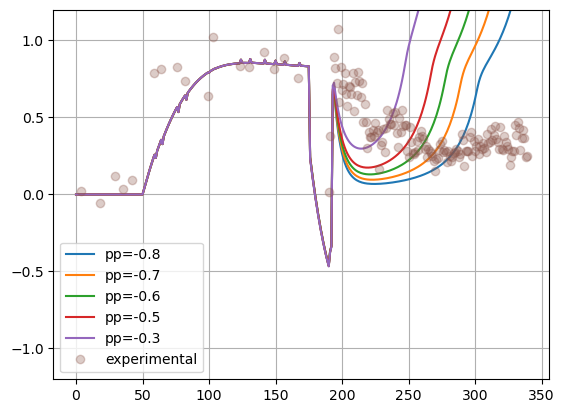

In [475]:
a_exp = all_a_exp[this_sub_indx]
a_exp_padded = pad(a_exp, pad_value=np.nan, n=warmup, where='start', axis=0)
for oo, out in enumerate(outputs):
    print(np.sqrt(np.nanmean((out.squeeze() - a_exp_padded)**2)))
    plt.plot(out,'-')
# plt.plot(a_exp, 'o',alpha=0.3)
plt.plot(a_exp_padded, 'o',alpha=0.3)
plt.ylim(-1.2,1.2)
plt.legend([f'pp={pp}' for pp in pp_list]+['experimental'], loc='lower left')
# plt.plot(outputs[0],'-',linewidth=3, color='black')
# plt.xlim(188,200)#,53)
plt.grid()

0.48533964
1.0855527
45.035442
11053.456
615379800.0


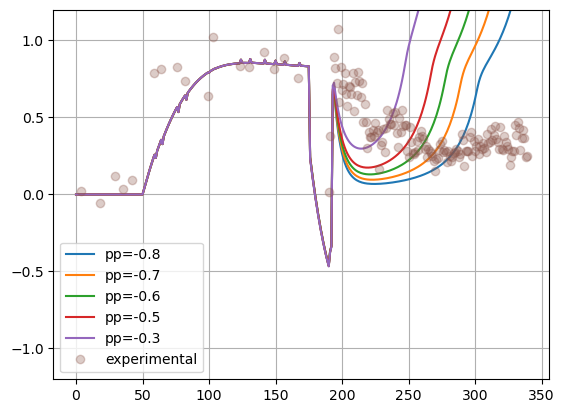

In [476]:
a_exp = all_a_exp[this_sub_indx]
a_exp_padded = pad(a_exp, pad_value=np.nan, n=warmup, where='start', axis=0)
for oo, out in enumerate(outputs):
    print(np.sqrt(np.nanmean((out.squeeze() - a_exp_padded)**2)))
    plt.plot(out,'-')
# plt.plot(a_exp, 'o',alpha=0.3)
plt.plot(a_exp_padded, 'o',alpha=0.3)
plt.ylim(-1.2,1.2)
plt.legend([f'pp={pp}' for pp in pp_list]+['experimental'], loc='lower left')
# plt.plot(outputs[0],'-',linewidth=3, color='black')
# plt.xlim(188,200)#,53)
plt.grid()

0.5627518
0.55175
0.5293436
0.48155376
0.80824167


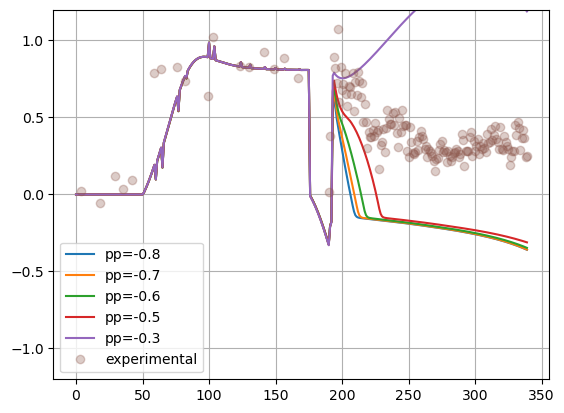

In [451]:
a_exp = all_a_exp[this_sub_indx]
a_exp_padded = pad(a_exp, pad_value=np.nan, n=warmup, where='start', axis=0)
for oo, out in enumerate(outputs):
    print(np.sqrt(np.nanmean((out.squeeze() - a_exp_padded)**2)))
    plt.plot(out,'-')
# plt.plot(a_exp, 'o',alpha=0.3)
plt.plot(a_exp_padded, 'o',alpha=0.3)
plt.ylim(-1.2,1.2)
plt.legend([f'pp={pp}' for pp in pp_list]+['experimental'], loc='lower left')
# plt.plot(outputs[0],'-',linewidth=3, color='black')
# plt.xlim(188,200)#,53)
plt.grid()

In [452]:
model.args.initiate_w_in_tuning_with_steady_state_vals = True

0.5627518
0.55175
0.5293436
0.48155376
0.80824167


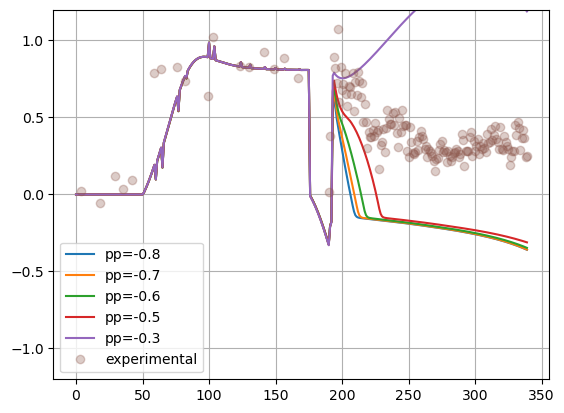

In [453]:
a_exp = all_a_exp[this_sub_indx]
a_exp_padded = pad(a_exp, pad_value=np.nan, n=warmup, where='start', axis=0)
for oo, out in enumerate(outputs):
    print(np.sqrt(np.nanmean((out.squeeze() - a_exp_padded)**2)))
    plt.plot(out,'-')
# plt.plot(a_exp, 'o',alpha=0.3)
plt.plot(a_exp_padded, 'o',alpha=0.3)
plt.ylim(-1.2,1.2)
plt.legend([f'pp={pp}' for pp in pp_list]+['experimental'], loc='lower left')
# plt.plot(outputs[0],'-',linewidth=3, color='black')
# plt.xlim(188,200)#,53)
plt.grid()

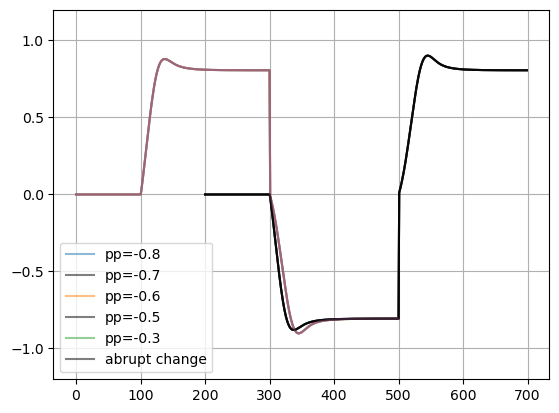

In [454]:
for oo, out in enumerate(outputs_ab):
    xdata = np.arange(out.shape[0])
    plt.plot(xdata, out,'-', alpha=0.5)
    plt.plot(xdata+200, -out,'k-', alpha=0.5)
plt.ylim(-1.2,1.2)
plt.legend([f'pp={pp}' for pp in pp_list]+['abrupt change'], loc='lower left')
plt.grid()

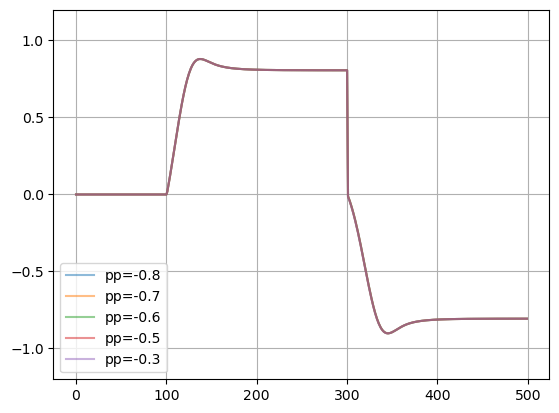

In [455]:
for oo, out in enumerate(outputs_ab):
    plt.plot(out,'-', alpha=0.5)
plt.ylim(-1.2,1.2)
plt.legend([f'pp={pp}' for pp in pp_list]+['abrupt change'], loc='lower left')
plt.grid()

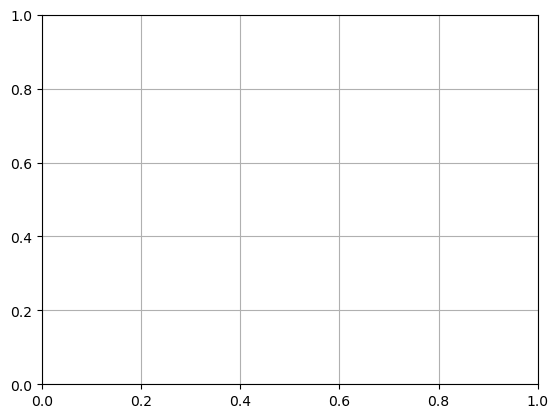

In [456]:
for oo, out in enumerate(outputs_ac):
    plt.plot(out,'-', alpha=0.5)
# plt.ylim(-1.2,1.2)
plt.grid()  


In [457]:
ys = torch.tensor(all_ys[this_sub_indx], device=next(model.parameters()).device)
ys_ab = torch.tensor(ys_ab, device=next(model.parameters()).device)
ys.shape

/tmp/ipykernel_3166241/3949350537.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ys_ab = torch.tensor(ys_ab, device=next(model.parameters()).device)


torch.Size([340])

In [458]:
model.w_in_scale

tensor([1.0000e-05], device='cuda:0')

In [459]:
model.log_learning_rate

Parameter containing:
tensor([[-4.]], device='cuda:0', requires_grad=True)

In [460]:
model._w_in.shape

torch.Size([128])

In [461]:
model.output_scale

Parameter containing:
tensor([0.8064], device='cuda:0', requires_grad=True)

In [462]:
model.args.apply_scaled_soft_plus_on_w_in_params

False